# A free-falling problem

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tools.general import Trajectory, Display
from tools.voronoi import DisplayVoronoi

Inspired by the highly addictive game [Cosmic Drift](https://store.steampowered.com/app/3601890/Cosmic_Drift/) by Shakawah, we consider the motion of a free-falling particle in a gravitational field generated by N planets (immobile point masses at the center of a rigid disk) until it either crashes in one of them or crosses the border of the frame.

Its full trajectory is then completely determined by its initial speed vector, starting from a fixed origin and ending freely within the frame.

The goal is to maximize the flight duration before crash or going out of bound (acknowledging the possibility of infinite trajectories for certain initial configurations).

Four search methods have been compared to maximize the flight duration: grid-based, Montecarlo, line-based and fractal.

In [2]:
N_planets = 3
planet_radius = 0.1
gravity_constant = 0.1
traj_boundaries = np.array([[-1,1],[-1,1]])
dt = 0.01
Tmax = 100

traj = Trajectory(N_planets, planet_radius, gravity_constant, traj_boundaries, dt, Tmax)
planets_loc = traj.gen_planets(traj.bounds, 0.3) ; p0 = traj.gen_shuttle(0.5)

# uncomment and modify p0 to load a previously saved configuration
#p0 = np.array([0.0, 0.0]); planets_loc = np.load('save/planets_loc/[{}, {}].npy'.format(p0[0],p0[1])); traj.reset(p0,loc = planets_loc)

Here is an example of initial configuration consisting of a starting point and three planets, with several examples of trajectories associated with different initial velocities each represented by a red arrow. (The gravitational potential is indicated as shades of grey in the background)

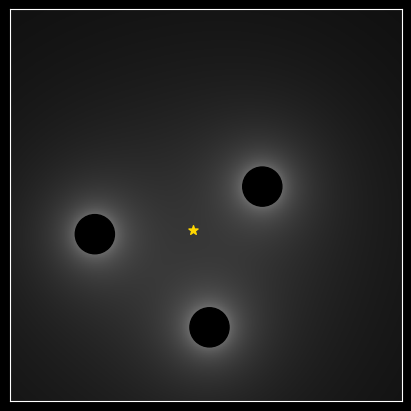

In [3]:
d = Display(traj)
d.plot_config()

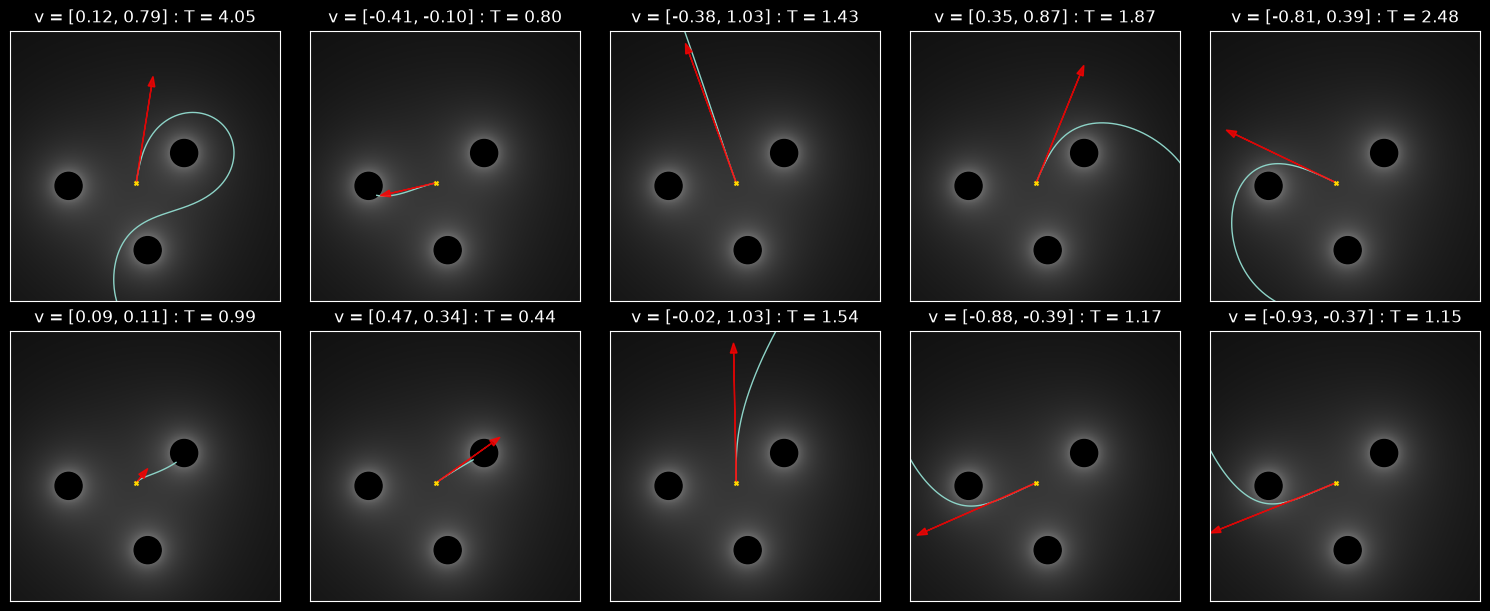

In [4]:
figs, axs = plt.subplots(2,5,figsize=(15,6),layout='constrained')

for i in range(2):
    for j in range(5):
        v0 = d.traj.span*(np.random.random(size=(2))-0.5)+np.mean(d.traj.bounds,axis=1) - d.traj.p0
        d.plot_traj(v0,axs[i,j])

<span style="font-size:1.5em;color:red">
    Our goal is to maximize the flight duration before crash or going out of bound.
</span> 
    <span style="font-size:0.8em;">(and investigate the possibility of infinite trajectories)</span>

As will be shown shown in the next section, the loss map is neither convex, differentiable, nor continuous. The following methods explore how to use the regularities and (so far empirical) properties of this specific problem to provide a heuristic solution to this optimization problem. Ideally in five minutes or less.

## I - Grid search

In [5]:
from tools.gridsearch import DisplayGridSearch

The most straightforward approach would be to compute the trajectory for all the initial velocities (end point of the red arrow) on a grid.

The top left quadrant contains shows the configuration of planet and initial position.\
The top right and bottom right display for each initial velocity respectively the end condition (the planet in which it crashes, the border or reaching Tmax which is considered infinite) of the trajectory and its total flight time (also called "loss" *par abus de langage*).\
The bottom left quadrant plots the trajectory of the best initial velocity (i.e. with the longest flight time) found on the grid (the arrow extremity is the solution circled in red on the top and bottom right maps).

In [6]:
n = 1000

1 maximum(s) - proposal [157, 293] : v = [-0.62,-0.29]


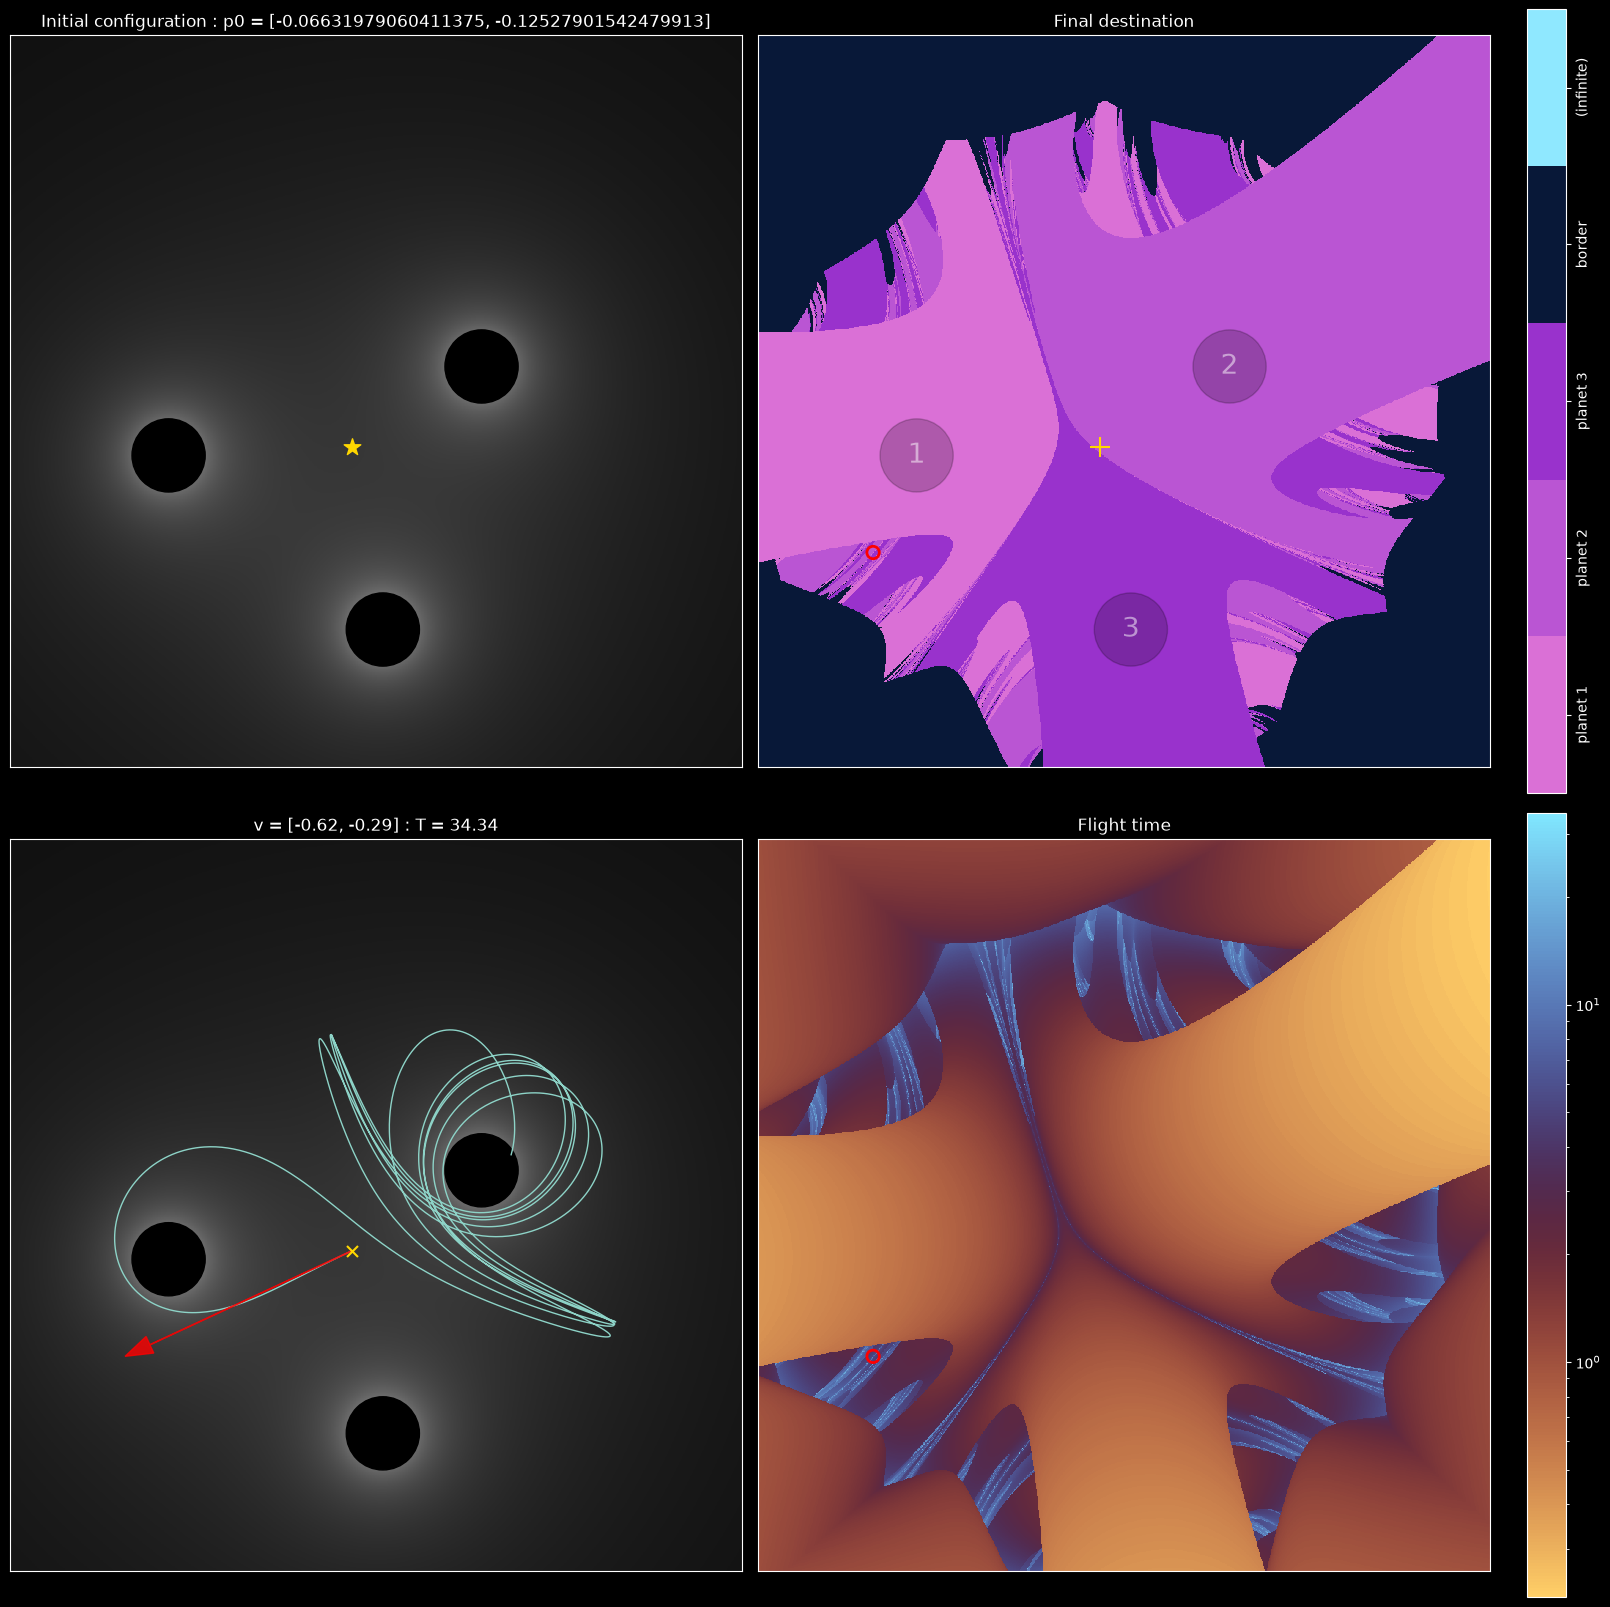

In [7]:
dg = DisplayGridSearch(traj,n)
dg.plot4(save=False)

This is a time-costly exploration, especially at this resolution but provides insightful informations.

Observations:

- The loss (flight-time in bottom right quadrant) is discontinuous over the optimization space, eventhough it features continuous regions.
- The regions of discontinuity in the loss are also regions of interest with higher flight-time and match to interface regions in final destination.
- The discontinuities between two crash regions (zones of same color in top right plot) are not clear cut but instead composed of many layers of smaller and smaller regions (probably an infinity). The bottom right plot hints that these layered discontinuities are not exclusive to the interface of different crash regions and can also happen inside a crash region.
- In some initial configurations, infinite trajectories can be found, usually regrouped in one or a few connex region(s)

An interpretation of these discontinuity regions is that for a wide range of initial input resulting in crashing in the same area continuously, but once you manage to avoid it, it opens the trajectory to many new possibilities.\
For instance reaching the angle that gets you around planet 1 and escaping instead of going straight into it, a wide range of trajectory can happen such as getting around planet 1 and crashing in planet 2, orbiting twice around planet 1 before eventually crashing into it, avoiding planet 1 pull by going faster and reaching a border, ...\
This also explains why these high sensitivity regions of discontinuity concentrate the higher flight-times and become regions of interest to investigate in order to solve the problem at hand.

To compare methods, we will limit ourselves to `10000 trajectory computations`, this corresponds to a 100x100 grid.

In [8]:
n = 100

1 maximum(s) - proposal [18, 12] : v = [-0.57,-0.63]


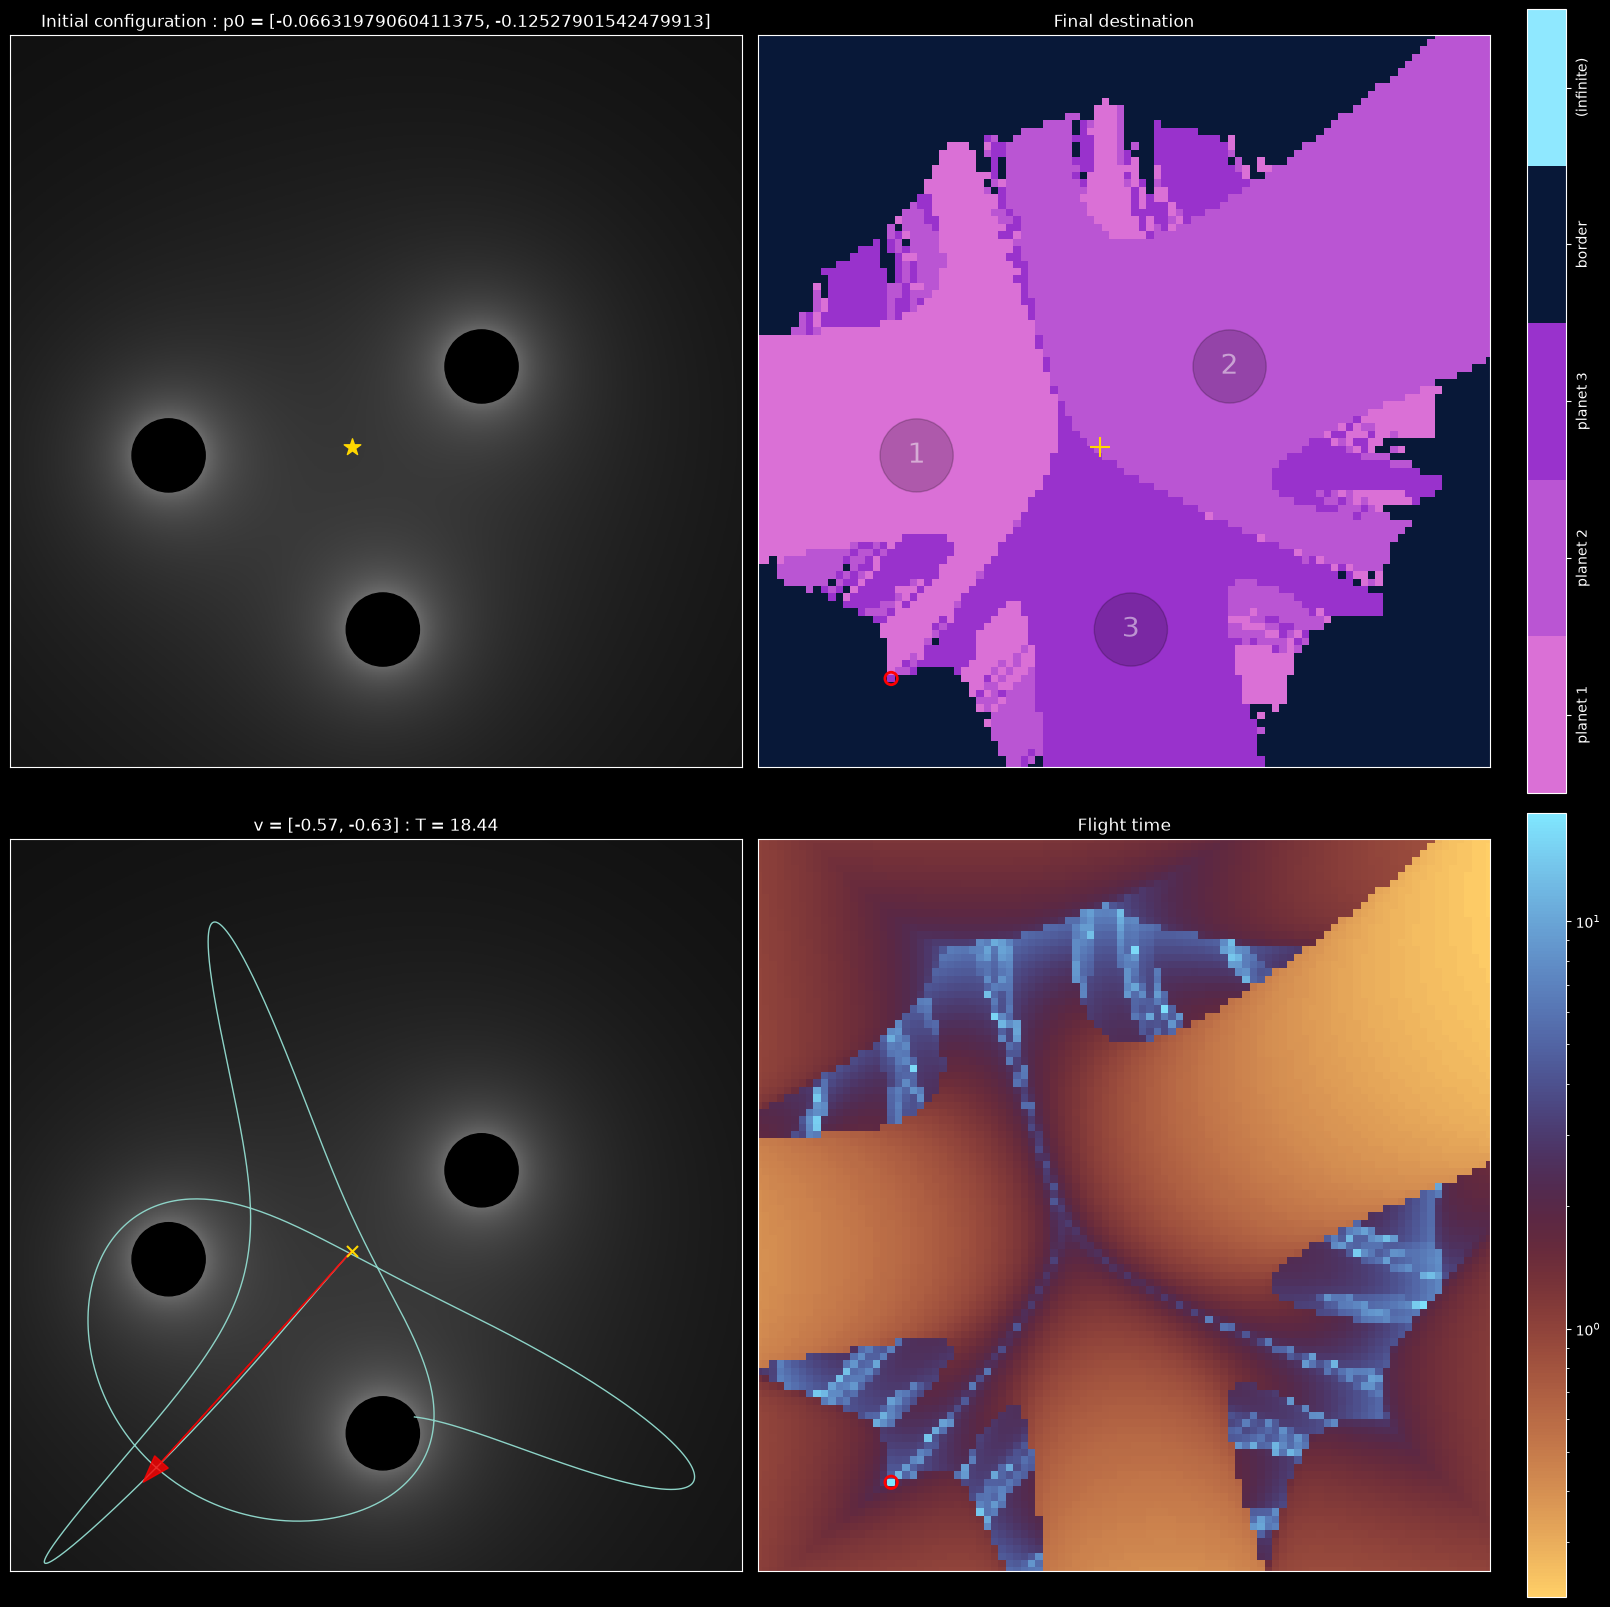

In [9]:
dg100 = DisplayGridSearch(traj,n)
dg100.plot4(save=False)

The advantage of the grid search is that it doesn't miss any region by sampling uniformally, the inconvenient is that it wastes time sampling low flight-time regions and inside the continuous components, while it could be more beneficial to focus on the interfaces and regions of interest.

## II - Monte Carlo search

In [10]:
from tools.voronoi import MonteCarloSearch

Another method, relatively similar to the grid search, is based on a uniform random sampling over the frame.\
The main difference is the use of a Voronoï diagram to represent the results instead of a grid, each image pixel getting the evaluation of the closest point in the sampling to generate the same image.\
This does not significantly improve the results but gets rid of the arbitrary grid for a random uniform sampling instead.

In [11]:
mc = MonteCarloSearch(traj,n*n)

1 maximum(s) - proposal [4960] : v = [-0.23,0.62]


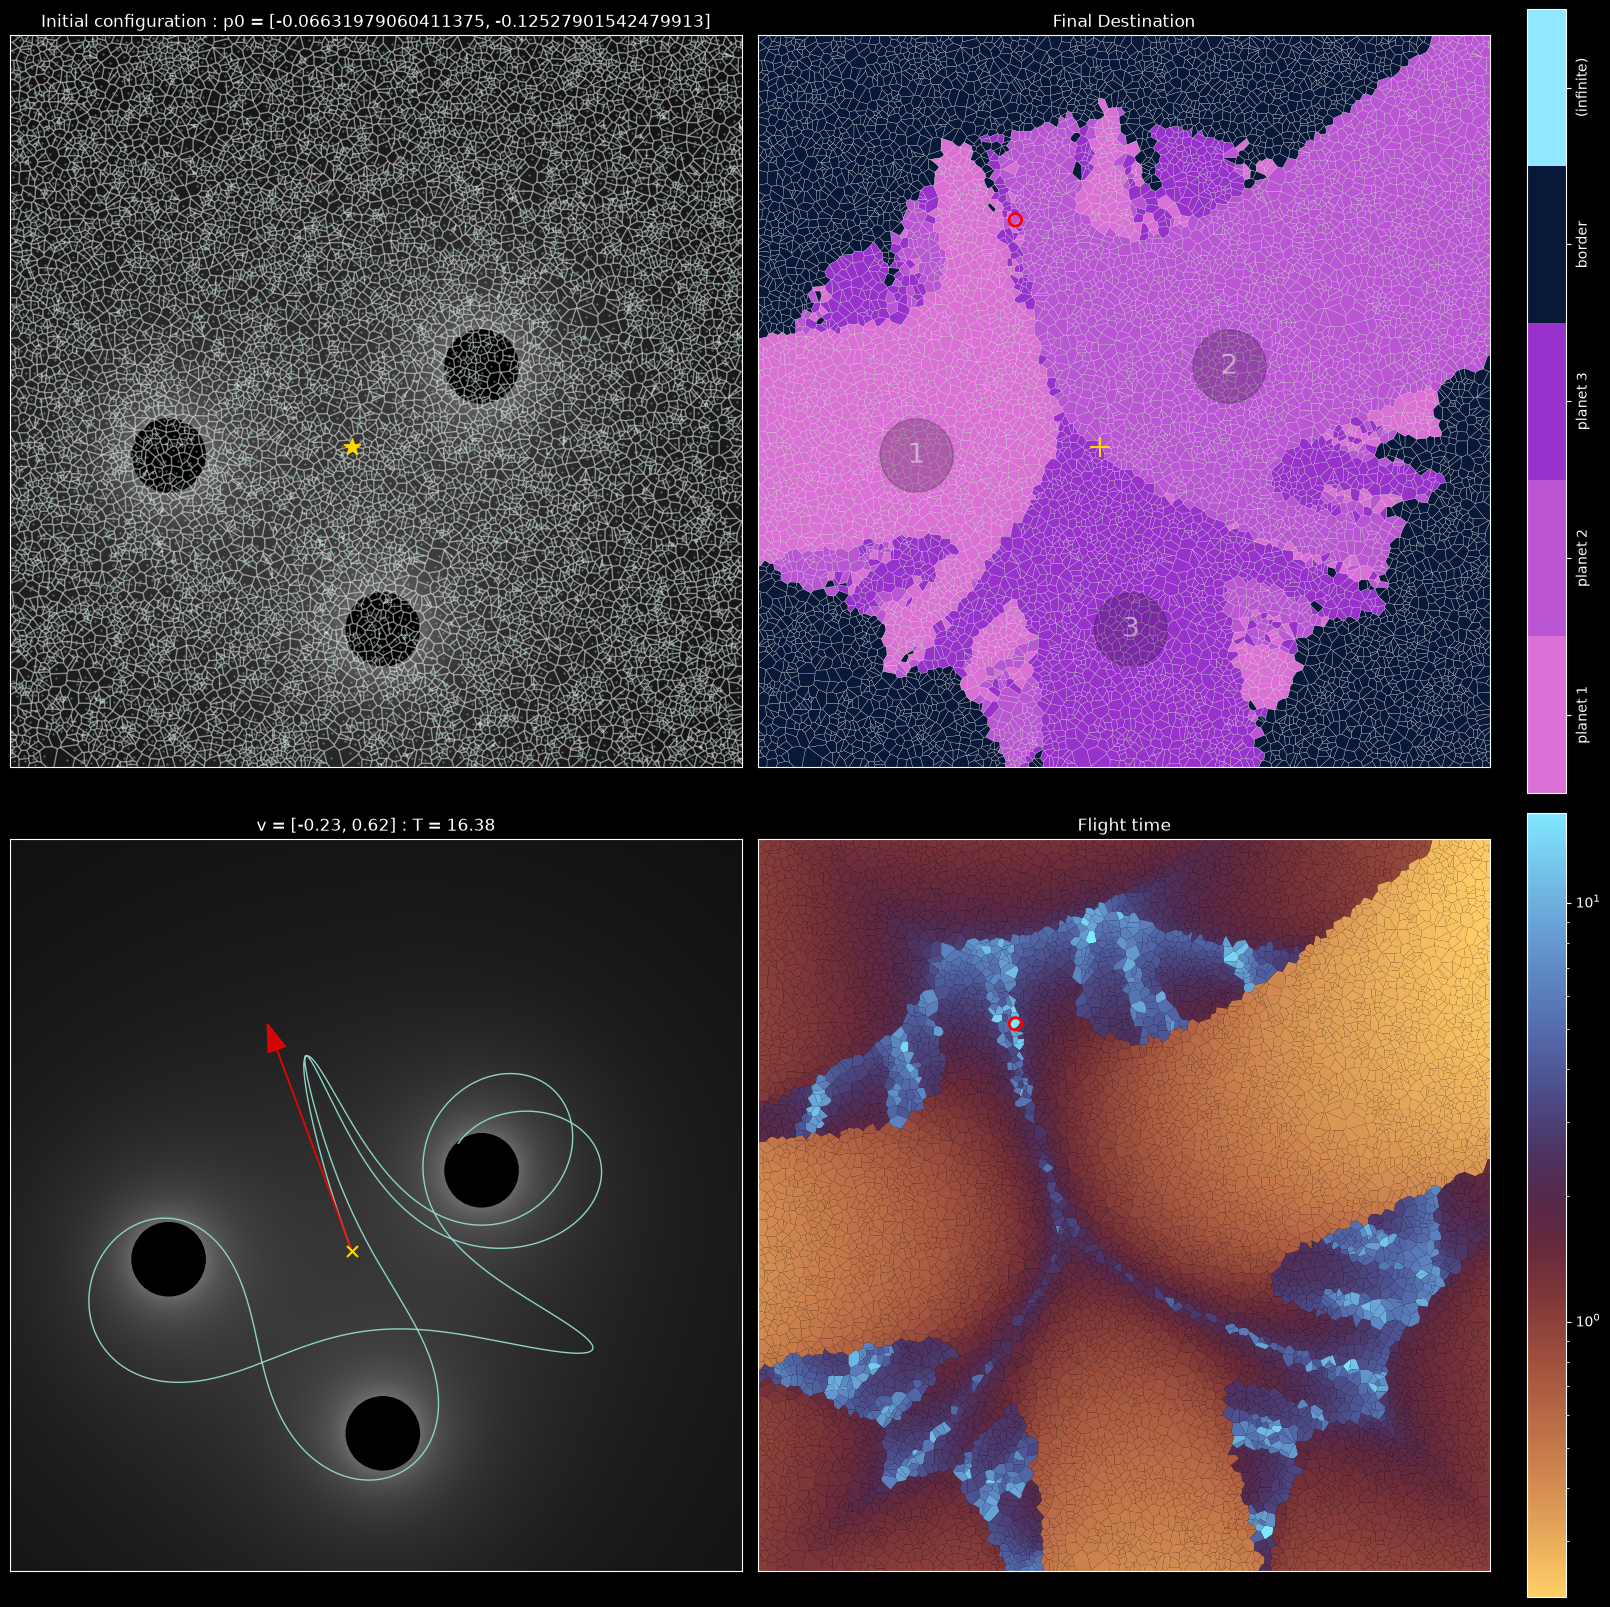

In [12]:
dmc = DisplayVoronoi(traj,mc)
dmc.plot4(save=False)

## III - Linesearch

In [13]:
from tools.linesearch import DisplayLineSearch

Since the higher flight-time match the regions of interface between different crash destinations (different colors in the top right plots), investigating these regions at high precision seems likely to provide interesting results.\
Our first real optimization method does so by taking two initial velocities belonging to different regions of crash and zooming in on the discontinuity between them.\
In other word a segment has two extremities of different labels and the method searches where on the line this discrete shift happens.

### Dichotomic line search

This methods recursively evaluates the crash condition of the trajectory associated with the middle of the segment.\
If has the same crash region as the left border, then it zooms on the right half-segment, otherwise it zooms on the left half-segment.\
This is the fastest method to zoom on a frontier, but can easily be tricked to zoom on a frontier where flight-time remains low. 

### Uniform linesearch

This is just a regular-spaced segmentation of the initial segment to find the maximum.

### Mixed version

In this hybrid p-adic method, a small number of uniform steps create a set of candidates for the new segment. The selected candidate is the one which has two extremities with different end-conditions (different colors), and with the extremity of higher flight-time among those which satisfy the first condition.

### Multisearch improvement
This is not another method for linesearch but an improvement on the dichotomic and mixed methods. All presented results in this section use it.

Since both the dichotomic search and to a lesser extent the mixed version tend to close in very fast to a high precision on a region of interest, they reach python's double precision in as fast as around 50 iterations.\
Since by then new evaluations are superfluous and redundant, the methods keep a list of unexplored segments when the color of a new evaluation matches neither of its closest neighbors, instead of arbitrary selecting only one side to explore. Once said precision is reached, it drops the branch it was exploring to move to another which can host better solutions. 

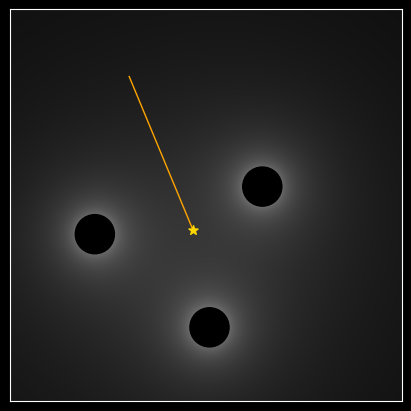

In [14]:
dl = DisplayLineSearch(traj,n*n)
dl.plot_ls_config()

Note that the fact that one of the extremity of the initial segment is set to v1=\[0,0\] is arbitrary and can be modified if deemed relevant.

In [15]:
dL = [DisplayLineSearch(traj,n*n,v1=dl.v0[0],v2=dl.v0[1]) for i in range(5)]
evals = np.array([dL[0].dicho_multisearch(), 
                  dL[1].mixed_mutlisearch(10), 
                  dL[2].mixed_mutlisearch(100),
                  dL[3].mixed_mutlisearch(1000),
                  dL[4].uniform_search()])
titles = ['Dichotomic','mix 10','mix 100','mix 1000','uniform']

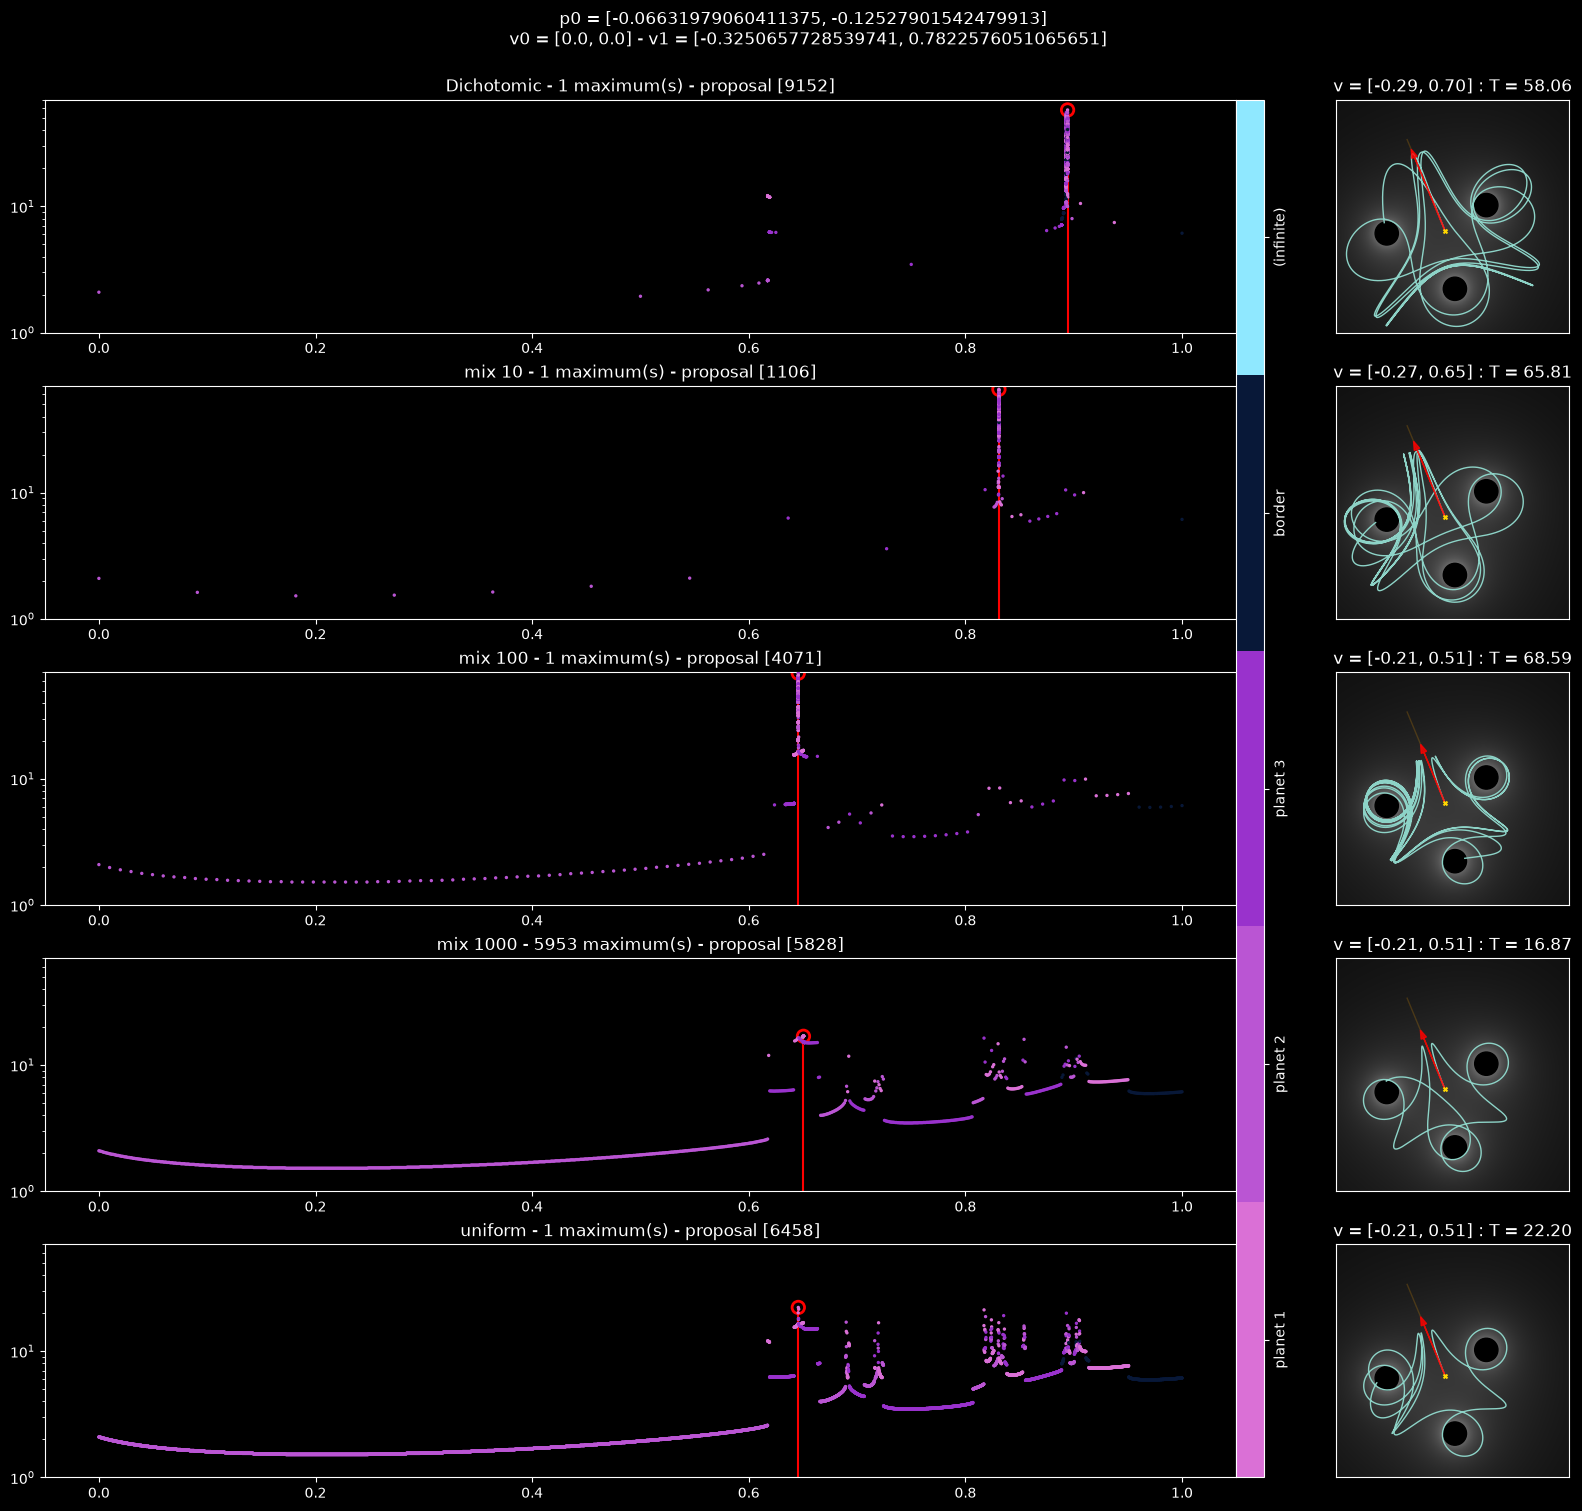

In [16]:
dl.plot_list(evals,titles,save=False)

The solutions produced tend to consistently outperform those of the grid search and full monte carlo by having a non-uniform sampling, getting a higher sampling density in regions of interest and lower sampling density in the flat parts of the loss.\
This is of course true provided that the initial segment actually crosses a region with high flight duration, which is not always the case.\
The draw of the initial segment remains quite arbitrary and the 1D limitation can effectively affect negatively performances. These issues can be mitigated by making multiple less precise linesearchs with different initial segments. Or by going 2D.

## IV - Fractal search

In [17]:
from tools.voronoi import FractalSearch

The fractal search method takes this frontier zooming approach to 2D.

### Fractal grid

This can be seen as the 2D analogy of the 1D dichotomic search. From a diagonal segment in 2D space, you create 3 new sampling points (if they have not been already sampled), the two points completing a square from this diagonal and the center of said square.\
Then each of the four segments between the square center and a corner is considered a candidate, if they are associated with different end conditions the segment is added to the list to generate new sampling points.\
The initial segment is set as the bottom left and top right corners of the frame.

This effectively creates a gridding with higher precision around borders and lower precision inside flat regions, which can then either be used to sample broadly or very narrowly depending on the minimal level level of recursion at which every candidate gets visited and the maximum level of recursion at which the branch is ended regardless of conditions to move on to another.

### Fractal Monte Carlo

Based on Delaunay triangulation and/or Voronoï diagram.\
No public version.

1 maximum(s) - proposal [6027] : v = [0.55,-0.52]


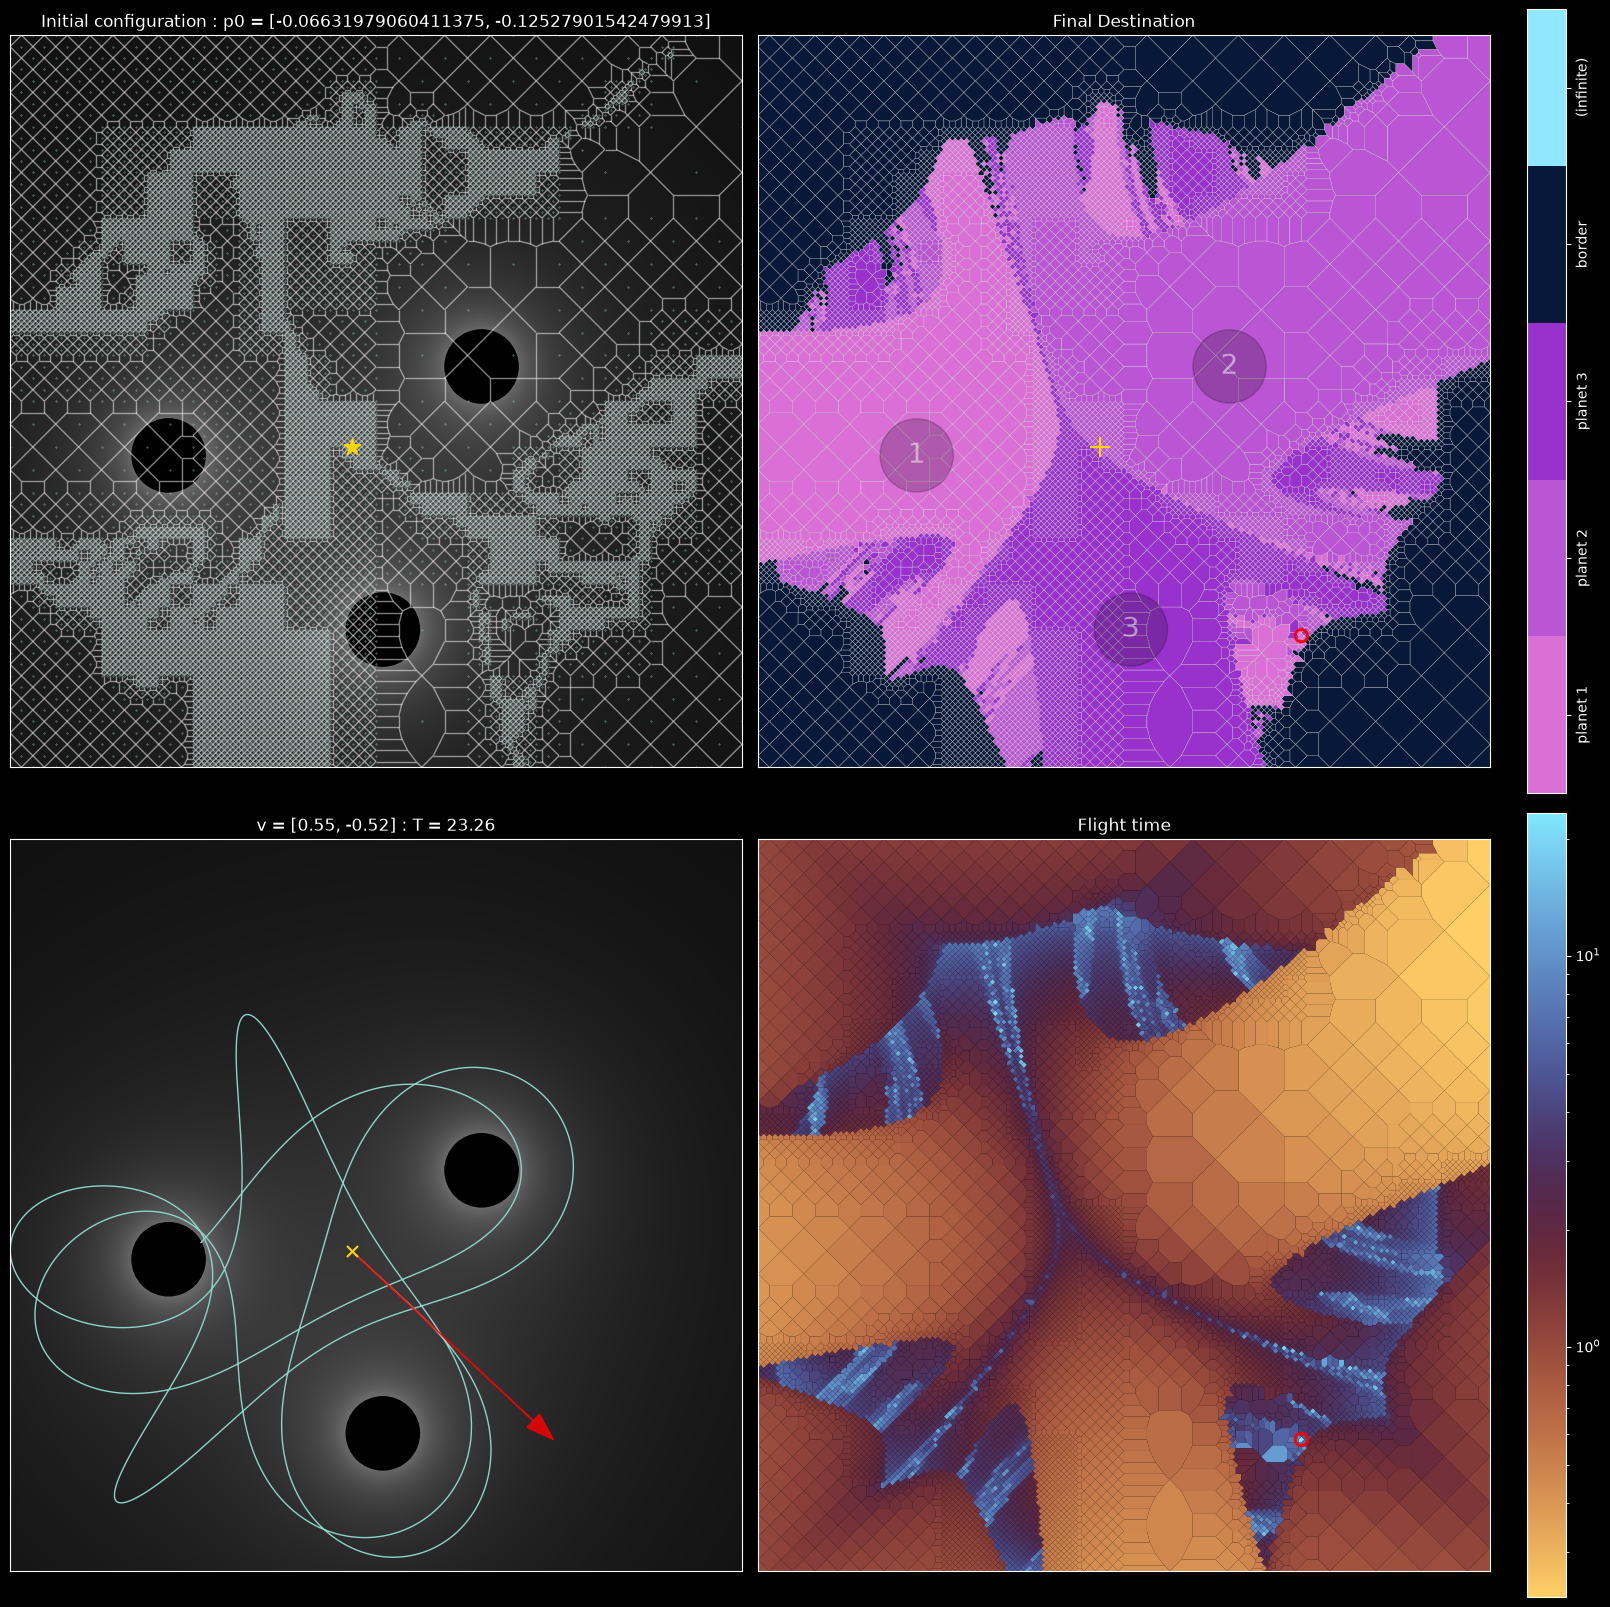

In [18]:
fr = FractalSearch(traj,n*n)
fr.fractal_grid(lvl0=0, lvlmax=8)
fr.get_vbest()
dfr8 = DisplayVoronoi(traj,fr)
dfr8.plot4(save=False)

1 maximum(s) - proposal [449] : v = [0.87,-0.14]


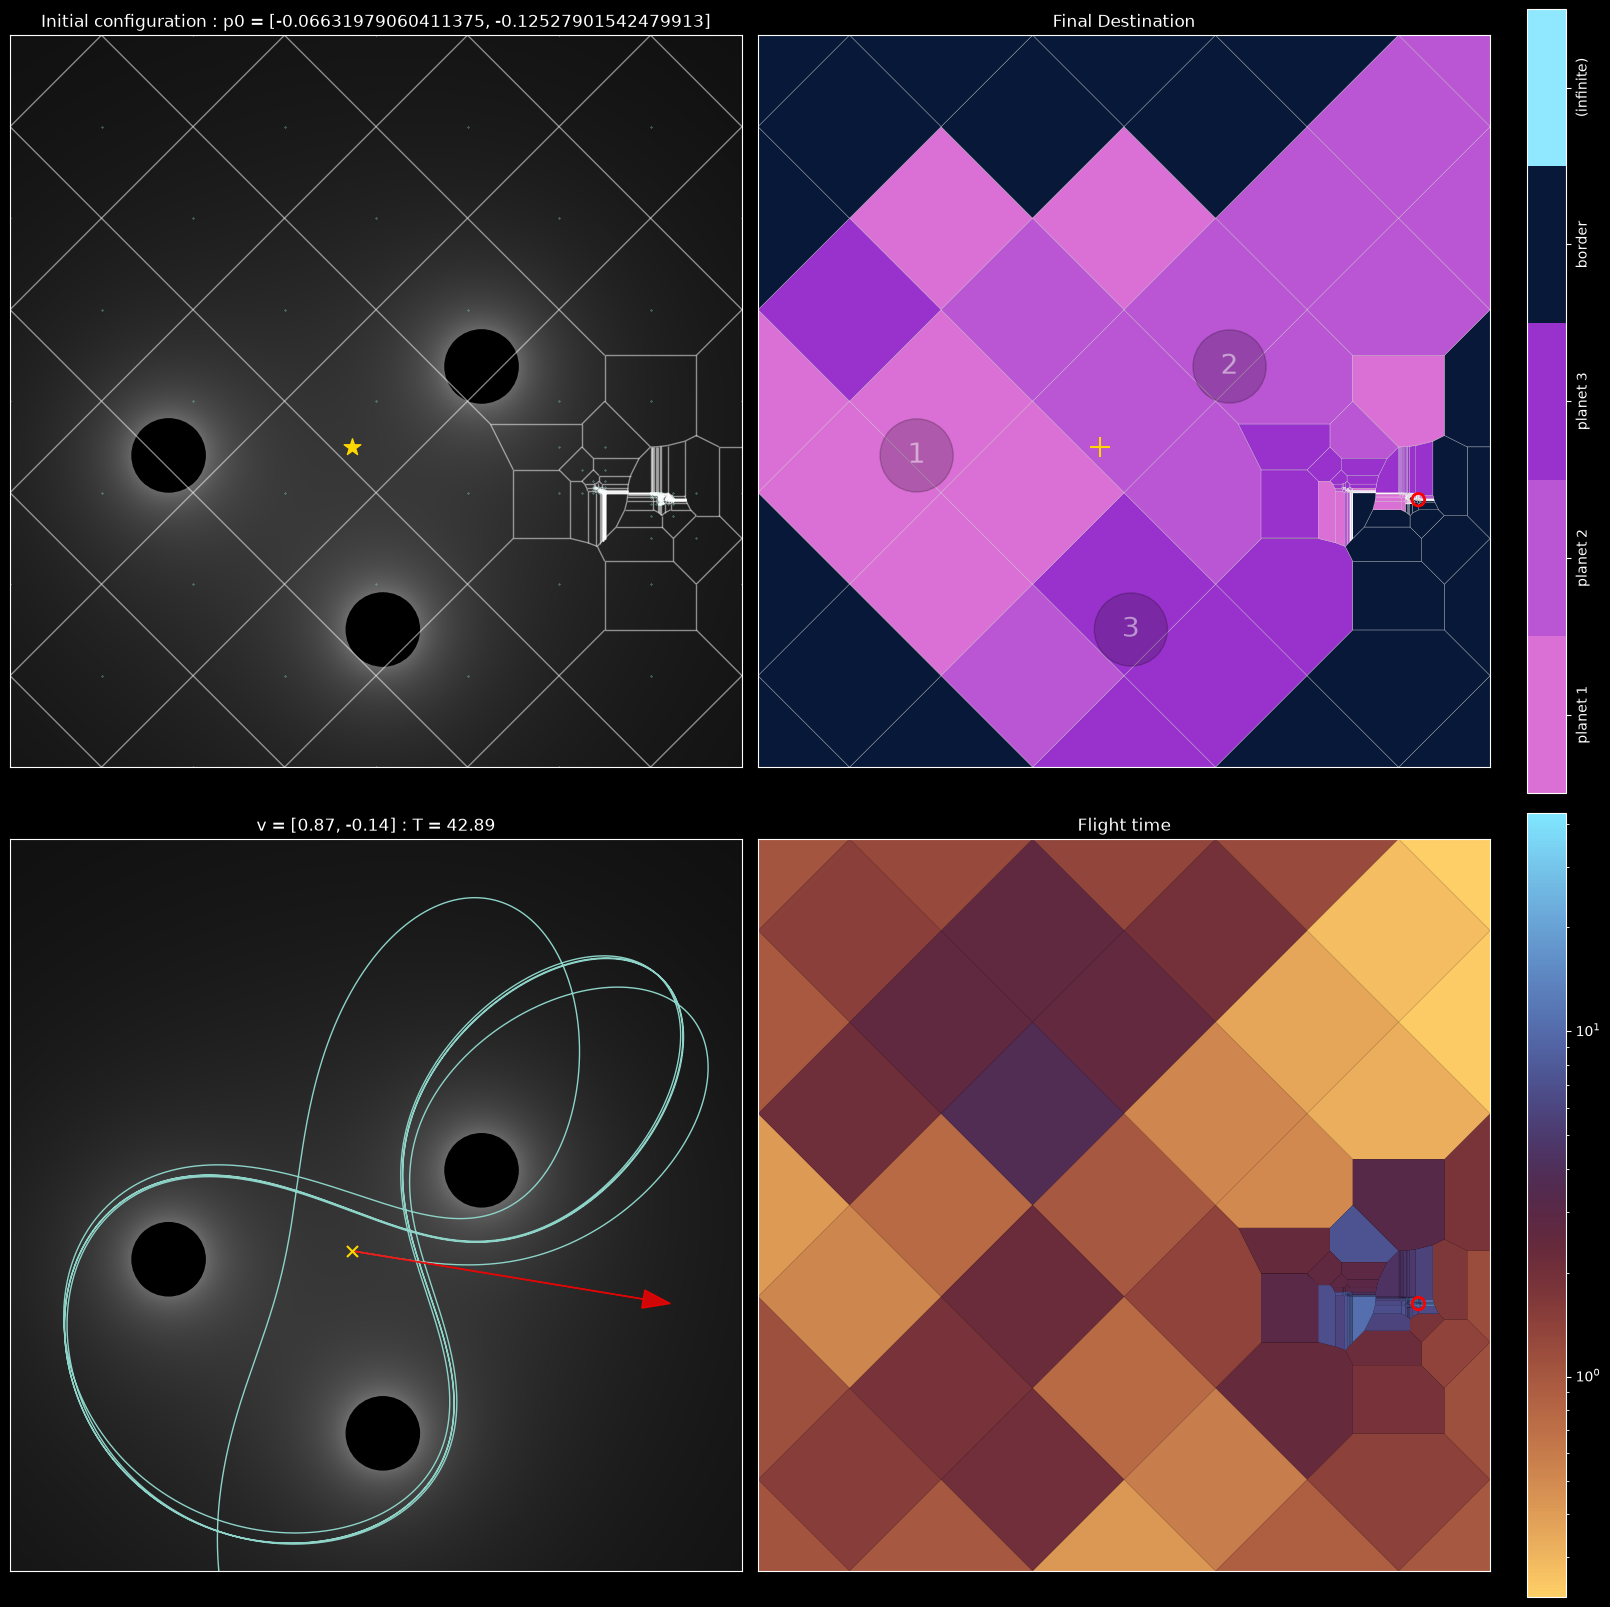

In [19]:
fr = FractalSearch(traj,n*n)
fr.fractal_grid(lvl0=3, lvlmax=16)
fr.get_vbest()
dfr16 = DisplayVoronoi(traj,fr)
dfr16.plot4(save=False)

In [ ]:
# Choose the trajectories you want to save as gif

#dfr16.gif_traj(dfr16.sol.vbest)
#i=2; dL[i].vbest_line(); dL[i].gif_traj(dL[i].vbest)
#dg.gif_traj(dg.vbest)